# Tahap 3 — Exploratory Data Analysis (EDA)
### Proyek: Prediksi Customer Churn pada Perusahaan Telekomunikasi

Lanjutan dari `02_data_cleaning.ipynb`. Tujuan tahap ini adalah mencari pola
yang menjawab **Pertanyaan Bisnis #1** ("faktor apa yang paling berhubungan
dengan churn?") secara visual, sebelum masuk ke feature engineering &
modeling.

Isi notebook:

1. Distribusi target (`Churn`).
2. Churn rate berdasarkan `Contract` dan `InternetService`.
3. Distribusi `tenure` dipecah per status churn.
4. `MonthlyCharges` vs `Churn` (boxplot).
5. Correlation heatmap kolom numerik.

**Catatan desain visual:** semua chart memakai palet kategorikal yang sudah
divalidasi tahan buta-warna (skill `dataviz` proyek ini) — slot 1 = biru,
slot 2 = oranye — dipakai konsisten sebagai warna `No` vs `Yes` di semua
chart, bukan warna default matplotlib yang acak.

## 1. Setup & Load Data Bersih

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", 25)

DATA_PATH = "../data/interim/telco_customer_churn_cleaned.csv"
FIG_DIR = "../reports/figures"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Matplotlib is building the font cache; this may take a moment.


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Palet warna (dari skill `dataviz` proyek ini)

Warna kategorikal dipakai dalam urutan tetap (bukan siklus default
matplotlib) agar konsisten & tahan buta-warna di semua chart:

- **Slot 1 — biru `#2a78d6`** → kelas `No` (tidak churn)
- **Slot 2 — oranye `#eb6834`** → kelas `Yes` (churn)
- Untuk bar chart satu-seri (churn rate per kategori) dipakai satu warna
  biru saja (bukan perbandingan identitas, tapi magnitude).
- Heatmap korelasi memakai pasangan diverging **biru ↔ merah** dengan
  titik tengah abu-abu netral di 0, sesuai aturan "diverging = dua hue +
  netral di tengah, bukan rainbow".

In [2]:
# Chrome & ink tokens dari references/palette.md (light mode)
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

# Categorical slot 1 & 2
BLUE = "#2a78d6"
ORANGE = "#eb6834"
CHURN_COLORS = {"No": BLUE, "Yes": ORANGE}
CHURN_ORDER = ["No", "Yes"]

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "grid.color": GRIDLINE,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2. Distribusi Target (`Churn`)

Chart pertama: seberapa imbalance target-nya. Ini menentukan strategi
Tahap 4 (class imbalance) dan metrik Tahap 6 (kenapa bukan accuracy).

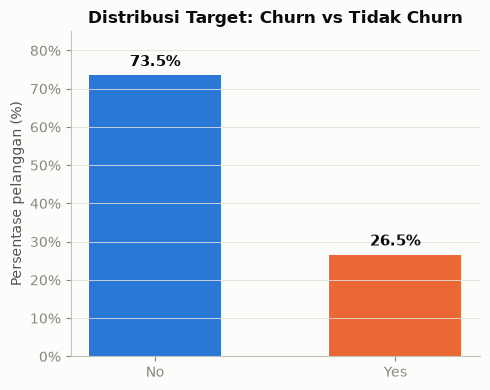

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [3]:
churn_pct = df["Churn"].value_counts(normalize=True).reindex(CHURN_ORDER) * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(CHURN_ORDER, churn_pct.values,
              color=[CHURN_COLORS[c] for c in CHURN_ORDER], width=0.55)

for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{pct:.1f}%", ha="center", va="bottom",
            color=INK_PRIMARY, fontsize=11, fontweight="bold")

ax.set_ylim(0, 85)
ax.set_ylabel("Persentase pelanggan (%)")
ax.set_title("Distribusi Target: Churn vs Tidak Churn", color=INK_PRIMARY, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="x", visible=False)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/01_churn_distribution.png", dpi=150, facecolor=SURFACE)
plt.show()

print(churn_pct.round(2))

**Insight:** sekitar **73% pelanggan tidak churn** dan **27% churn** —
imbalance yang konsisten dengan brief. Ini alasan utama Tahap 4 perlu
`class_weight`/SMOTE dan Tahap 6 tidak boleh hanya melihat accuracy.

## 3. Churn Rate vs `Contract`

Ini bar chart satu-seri (mengukur magnitude churn rate per kategori
kontrak), jadi dipakai satu hue (biru) — bukan perbandingan dua identitas
seperti chart sebelumnya.

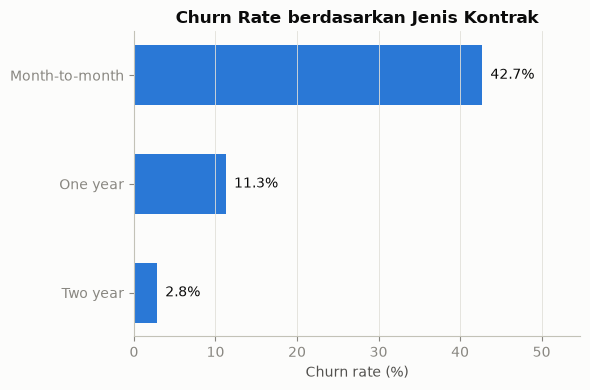

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


In [4]:
contract_churn = (
    df.groupby("Contract")["Churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(contract_churn.index[::-1], contract_churn.values[::-1], color=BLUE, height=0.55)

for bar, val in zip(bars, contract_churn.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", ha="left", color=INK_PRIMARY, fontsize=10)

ax.set_xlabel("Churn rate (%)")
ax.set_xlim(0, max(contract_churn.values) + 12)
ax.set_title("Churn Rate berdasarkan Jenis Kontrak", color=INK_PRIMARY, fontweight="bold")
ax.grid(axis="y", visible=False)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/02_churn_rate_by_contract.png", dpi=150, facecolor=SURFACE)
plt.show()

print(contract_churn.round(2))

**Insight:** pelanggan **`Month-to-month`** churn jauh lebih sering
dibanding `One year`/`Two year`. Ini sinyal paling kuat sejauh ini —
kontrak jangka panjang tampaknya jadi "pengikat" yang menahan pelanggan.

## 4. Churn Rate vs `InternetService`

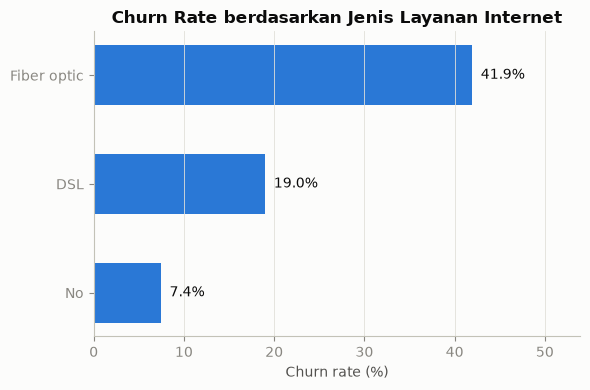

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64


In [5]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda s: (s == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(internet_churn.index[::-1], internet_churn.values[::-1], color=BLUE, height=0.55)

for bar, val in zip(bars, internet_churn.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", ha="left", color=INK_PRIMARY, fontsize=10)

ax.set_xlabel("Churn rate (%)")
ax.set_xlim(0, max(internet_churn.values) + 12)
ax.set_title("Churn Rate berdasarkan Jenis Layanan Internet", color=INK_PRIMARY, fontweight="bold")
ax.grid(axis="y", visible=False)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/03_churn_rate_by_internet_service.png", dpi=150, facecolor=SURFACE)
plt.show()

print(internet_churn.round(2))

**Insight:** pelanggan **`Fiber optic`** punya churn rate tertinggi,
lebih tinggi dari `DSL` maupun `No` internet service. Kemungkinan terkait
harga fiber yang lebih mahal atau ekspektasi kualitas layanan yang tidak
terpenuhi — perlu dicek silang dengan `MonthlyCharges` di bagian 6.

## 5. Distribusi `tenure` per Status Churn

Histogram dipecah per `Churn` (identitas dua kelas → dipakai warna
biru/oranye yang sama seperti bagian 2, konsisten di seluruh notebook).

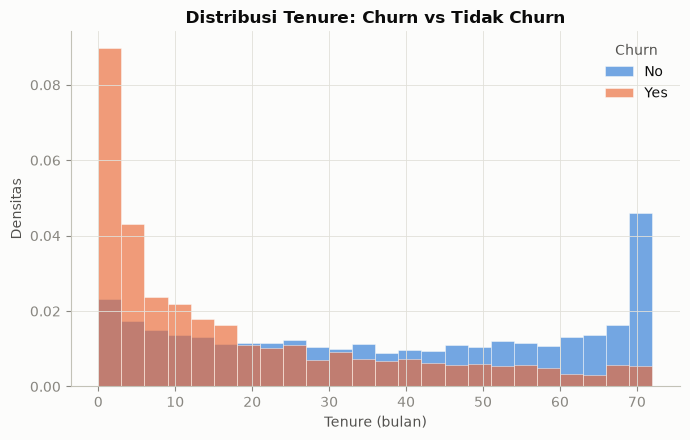

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for label in CHURN_ORDER:
    subset = df.loc[df["Churn"] == label, "tenure"]
    ax.hist(subset, bins=24, range=(0, 72), alpha=0.65,
            color=CHURN_COLORS[label], edgecolor=SURFACE, linewidth=0.5,
            label=label, density=True)

ax.set_xlabel("Tenure (bulan)")
ax.set_ylabel("Densitas")
ax.set_title("Distribusi Tenure: Churn vs Tidak Churn", color=INK_PRIMARY, fontweight="bold")
legend = ax.legend(title="Churn", frameon=False)
legend.get_title().set_color(INK_SECONDARY)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/04_tenure_distribution_by_churn.png", dpi=150, facecolor=SURFACE)
plt.show()

**Insight:** pelanggan yang churn (oranye) menumpuk di **tenure rendah**
(baru berlangganan beberapa bulan), sementara pelanggan yang bertahan
(biru) tersebar lebih merata dan justru menumpuk lagi di tenure tinggi
(pelanggan loyal jangka panjang). Ini konsisten dengan temuan `Contract`:
pelanggan baru month-to-month paling rentan churn di awal masa
berlangganan.

## 6. `MonthlyCharges` vs `Churn` (Boxplot)

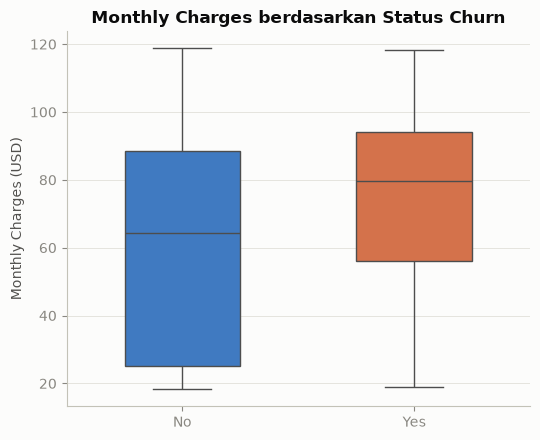

,mean,50%,std
Churn,,,
No,61.265124,64.425,31.092648
Yes,74.441332,79.650,24.666053


In [7]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

sns.boxplot(
    data=df, x="Churn", y="MonthlyCharges", order=CHURN_ORDER,
    hue="Churn", palette=CHURN_COLORS, legend=False,
    width=0.5, fliersize=3, ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Monthly Charges (USD)")
ax.set_title("Monthly Charges berdasarkan Status Churn", color=INK_PRIMARY, fontweight="bold")
ax.grid(axis="x", visible=False)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/05_monthlycharges_boxplot_by_churn.png", dpi=150, facecolor=SURFACE)
plt.show()

df.groupby("Churn")["MonthlyCharges"].describe()[["mean", "50%", "std"]]

**Insight:** median `MonthlyCharges` pelanggan yang churn **lebih tinggi**
dibanding yang tidak churn. Digabung dengan temuan `Fiber optic` di bagian
4, pola yang muncul: **pelanggan fiber dengan tagihan bulanan tinggi dan
kontrak month-to-month** adalah kombinasi paling berisiko.

## 7. Correlation Heatmap (Kolom Numerik)

Untuk chart ini, `Churn` dan `SeniorCitizen` di-encode sementara jadi 0/1
**hanya di dalam sel ini** (tidak mengubah `df` utama) agar bisa dilihat
korelasinya secara numerik terhadap target — encoding permanen untuk
modeling tetap jadi bagian Tahap 4.

Diverging colormap biru↔merah dengan titik tengah netral di 0, sesuai
aturan "diverging = dua hue + abu-abu di tengah", bukan rainbow.

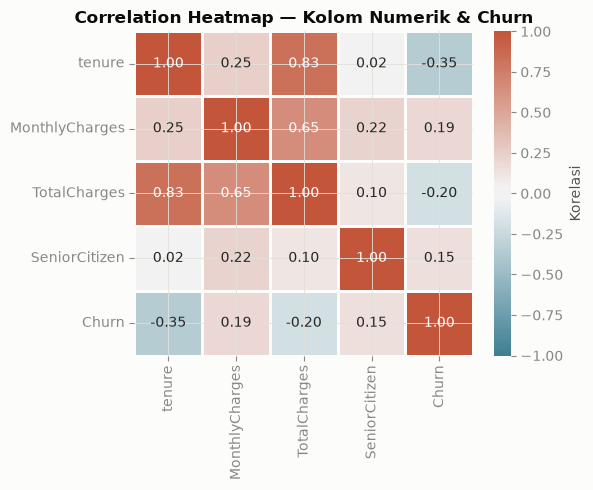

In [8]:
corr_df = df[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
corr_df["SeniorCitizen"] = (df["SeniorCitizen"] == "Yes").astype(int)
corr_df["Churn"] = (df["Churn"] == "Yes").astype(int)

corr = corr_df.corr()

diverging_cmap = sns.diverging_palette(220, 20, s=75, l=50, sep=10, as_cmap=True)  # blue <-> red

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap=diverging_cmap, center=0,
    vmin=-1, vmax=1, linewidths=1, linecolor=SURFACE,
    cbar_kws={"label": "Korelasi"}, ax=ax,
)
ax.set_title("Correlation Heatmap — Kolom Numerik & Churn", color=INK_PRIMARY, fontweight="bold")

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/06_correlation_heatmap.png", dpi=150, facecolor=SURFACE)
plt.show()

**Insight:**

- `tenure` berkorelasi **negatif** dengan `Churn` — semakin lama
  berlangganan, semakin kecil kemungkinan churn (konsisten dengan
  histogram di bagian 5).
- `MonthlyCharges` berkorelasi **positif** dengan `Churn` — tagihan
  bulanan lebih tinggi berasosiasi dengan churn lebih tinggi (konsisten
  dengan boxplot di bagian 6).
- `tenure` dan `TotalCharges` berkorelasi sangat kuat (masuk akal: makin
  lama berlangganan, makin besar akumulasi total tagihan) — kandidat kuat
  untuk fitur turunan `TotalCharges / tenure` di Tahap 4, bukan dipakai
  mentah berdampingan (redundan).

## 8. Ringkasan Tahap 3

**6 visualisasi dibuat** (disimpan di `reports/figures/`):

1. Distribusi target `Churn` (73% No / 27% Yes).
2. Churn rate per `Contract` — month-to-month paling berisiko.
3. Churn rate per `InternetService` — fiber optic paling berisiko.
4. Distribusi `tenure` per status churn — churn menumpuk di tenure rendah.
5. Boxplot `MonthlyCharges` per status churn — churn punya tagihan lebih
   tinggi.
6. Correlation heatmap — `tenure` negatif, `MonthlyCharges` positif
   terhadap churn.

**Menjawab Pertanyaan Bisnis #1** (faktor yang paling berhubungan dengan
churn), tiga sinyal paling konsisten dan saling menguatkan:

- **Jenis kontrak** (month-to-month jauh lebih berisiko).
- **Tenure rendah** (pelanggan baru paling rentan).
- **Tagihan bulanan tinggi**, terutama pada pelanggan **fiber optic**.

**Lanjut ke Tahap 4 — Feature Engineering:**

1. One-hot encoding kolom kategori.
2. Fitur turunan: `TotalCharges / tenure`, binning `tenure` (baru/menengah/
   lama).
3. Tangani class imbalance (`class_weight` atau SMOTE).